In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load features
df = pd.read_parquet('../data/features.parquet')

# Store 1 only
store1 = df[df['Store'] == 1].sort_values('Date').copy()

# Prophet format
prophet_df = store1[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

print(f"Store 1 rows: {len(prophet_df)}")
print(f"Date range: {prophet_df['ds'].min()} to {prophet_df['ds'].max()}")
print(prophet_df.head(3))

Store 1 rows: 781
Date range: 2013-01-02 00:00:00 to 2015-07-31 00:00:00
          ds     y
0 2013-01-02  5530
1 2013-01-03  4327
2 2013-01-04  4486


In [2]:
# Train/test split - temporal
train_df = prophet_df[prophet_df['ds'] < '2015-01-01'].copy()
test_df = prophet_df[prophet_df['ds'] >= '2015-01-01'].copy()

print(f"Train: {len(train_df)} rows ({train_df['ds'].min().date()} to {train_df['ds'].max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df['ds'].min().date()} to {test_df['ds'].max().date()})")

# Train Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.fit(train_df)
print("\nProphet model trained.")

22:42:05 - cmdstanpy - INFO - Chain [1] start processing


Train: 606 rows (2013-01-02 to 2014-12-31)
Test:  175 rows (2015-01-02 to 2015-07-31)


22:42:05 - cmdstanpy - INFO - Chain [1] done processing



Prophet model trained.


In [3]:
# Forecast on test period
future = model.make_future_dataframe(periods=len(test_df), freq='D')
forecast = model.predict(future)

# Get test predictions
forecast_test = forecast[forecast['ds'] >= '2015-01-01'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_test = forecast_test.merge(test_df, on='ds')

# Metrics
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

prophet_mape = mape(forecast_test['y'], forecast_test['yhat'])
prophet_rmse = rmse(forecast_test['y'], forecast_test['yhat'])
prophet_mae = mae(forecast_test['y'], forecast_test['yhat'])

print(f"Prophet Metrics - Store 1 (Test: Jan-Jul 2015)")
print(f"MAPE: {prophet_mape:.2f}%")
print(f"RMSE: {prophet_rmse:.0f}")
print(f"MAE:  {prophet_mae:.0f}")

Prophet Metrics - Store 1 (Test: Jan-Jul 2015)
MAPE: 17.16%
RMSE: 879
MAE:  708


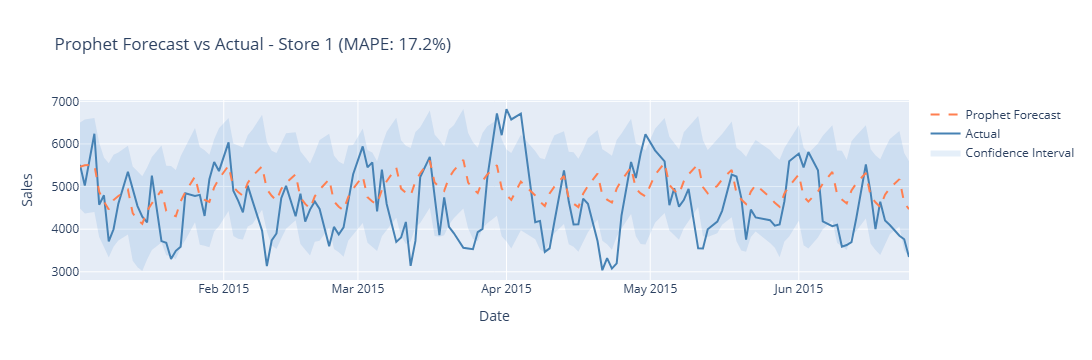

In [4]:
# Plot forecast vs actual
fig = go.Figure()

# Confidence interval
fig.add_trace(go.Scatter(
    x=forecast_test['ds'],
    y=forecast_test['yhat_upper'],
    fill=None,
    mode='lines',
    line_color='rgba(0,100,200,0)',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=forecast_test['ds'],
    y=forecast_test['yhat_lower'],
    fill='tonexty',
    mode='lines',
    line_color='rgba(0,100,200,0)',
    fillcolor='rgba(0,100,200,0.1)',
    name='Confidence Interval'
))

# Actual
fig.add_trace(go.Scatter(
    x=forecast_test['ds'],
    y=forecast_test['y'],
    mode='lines',
    name='Actual',
    line=dict(color='steelblue', width=2)
))

# Forecast
fig.add_trace(go.Scatter(
    x=forecast_test['ds'],
    y=forecast_test['yhat'],
    mode='lines',
    name='Prophet Forecast',
    line=dict(color='coral', width=2, dash='dash')
))

fig.update_layout(
    title=f'Prophet Forecast vs Actual - Store 1 (MAPE: {prophet_mape:.1f}%)',
    xaxis_title='Date',
    yaxis_title='Sales',
    hovermode='x unified'
)
fig.show()

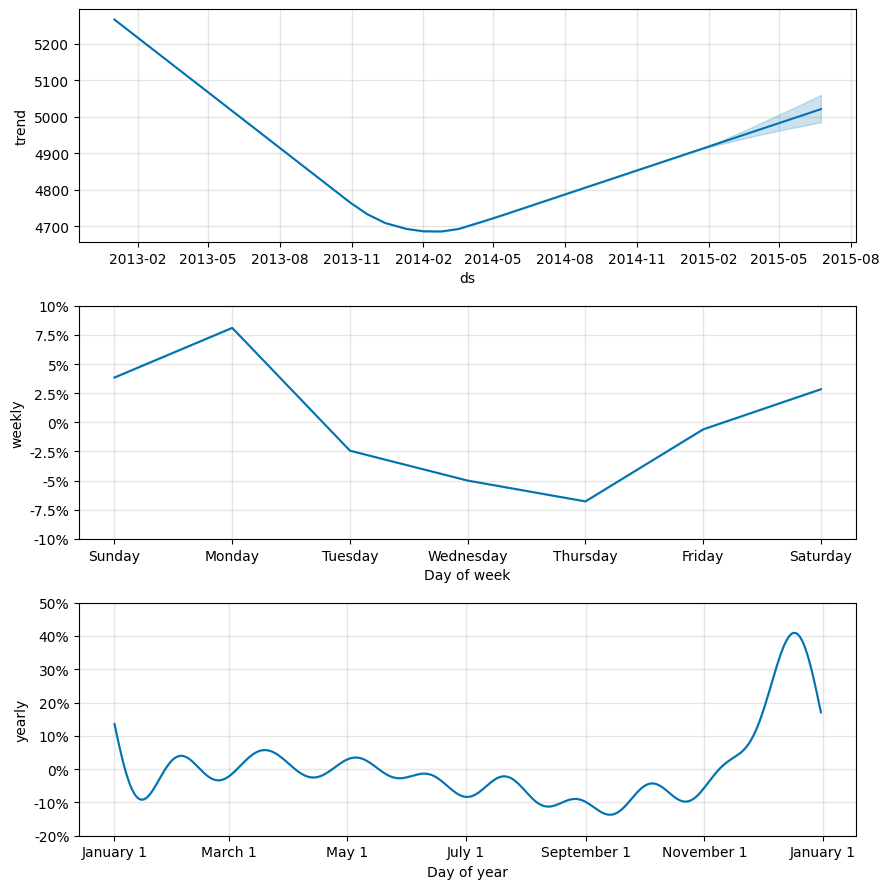

In [5]:
# Prophet components
fig_components = model.plot_components(forecast)

In [6]:
# Walk-forward CV - monthly steps
from datetime import datetime

cv_results = []

# Define folds: train up to cutoff, test next 30 days
cutoffs = pd.date_range(start='2014-06-01', end='2014-11-01', freq='MS')

print(f"Running {len(cutoffs)} CV folds...")

for cutoff in cutoffs:
    train_fold = prophet_df[prophet_df['ds'] < cutoff].copy()
    test_fold = prophet_df[
        (prophet_df['ds'] >= cutoff) &
        (prophet_df['ds'] < cutoff + pd.DateOffset(months=1))
    ].copy()

    if len(test_fold) == 0:
        continue

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )
    m.fit(train_fold)

    future_fold = m.make_future_dataframe(periods=len(test_fold), freq='D')
    forecast_fold = m.predict(future_fold)

    pred = forecast_fold[forecast_fold['ds'] >= cutoff][['ds', 'yhat']].head(len(test_fold))
    merged = test_fold.merge(pred, on='ds')

    fold_mape = mape(merged['y'], merged['yhat'])
    cv_results.append({
        'cutoff': cutoff.strftime('%Y-%m'),
        'mape': round(fold_mape, 2),
        'n_train': len(train_fold),
        'n_test': len(merged)
    })
    print(f"  Fold {cutoff.strftime('%Y-%m')}: MAPE={fold_mape:.1f}%")

cv_df = pd.DataFrame(cv_results)
print(f"\nMean CV MAPE: {cv_df['mape'].mean():.2f}%")
print(f"Std CV MAPE:  {cv_df['mape'].std():.2f}%")

23:00:54 - cmdstanpy - INFO - Chain [1] start processing
23:00:54 - cmdstanpy - INFO - Chain [1] done processing
23:00:54 - cmdstanpy - INFO - Chain [1] start processing


Running 6 CV folds...
  Fold 2014-06: MAPE=16.1%


23:00:54 - cmdstanpy - INFO - Chain [1] done processing
23:00:54 - cmdstanpy - INFO - Chain [1] start processing
23:00:54 - cmdstanpy - INFO - Chain [1] done processing
23:00:54 - cmdstanpy - INFO - Chain [1] start processing


  Fold 2014-07: MAPE=10.8%
  Fold 2014-08: MAPE=15.1%


23:00:54 - cmdstanpy - INFO - Chain [1] done processing
23:00:54 - cmdstanpy - INFO - Chain [1] start processing
23:00:54 - cmdstanpy - INFO - Chain [1] done processing


  Fold 2014-09: MAPE=15.2%
  Fold 2014-10: MAPE=12.5%


23:00:55 - cmdstanpy - INFO - Chain [1] start processing
23:00:55 - cmdstanpy - INFO - Chain [1] done processing


  Fold 2014-11: MAPE=14.6%

Mean CV MAPE: 14.04%
Std CV MAPE:  2.00%


In [7]:
# Save Prophet results
prophet_results = {
    'model': 'Prophet',
    'test_mape': round(prophet_mape, 2),
    'test_rmse': round(prophet_rmse, 0),
    'test_mae': round(prophet_mae, 0),
    'cv_mape_mean': round(cv_df['mape'].mean(), 2),
    'cv_mape_std': round(cv_df['mape'].std(), 2)
}

import json
with open('../data/prophet_results.json', 'w') as f:
    json.dump(prophet_results, f)

print("Saved to data/prophet_results.json")
print(f"\nProphet Summary - Store 1:")
for k, v in prophet_results.items():
    print(f"  {k}: {v}")

Saved to data/prophet_results.json

Prophet Summary - Store 1:
  model: Prophet
  test_mape: 17.16
  test_rmse: 879.0
  test_mae: 708.0
  cv_mape_mean: 14.04
  cv_mape_std: 2.0
